<a href="https://colab.research.google.com/github/lool-hash/DL-project-/blob/main/Hybrid_CNN_LSTM_Final_REHAB24(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile

BASE_PATH = "/content/drive/MyDrive/REHAB24-6"
os.makedirs(BASE_PATH, exist_ok=True)

files = {
    "2d_joints.zip": "https://zenodo.org/records/13305826/files/2d_joints.zip",
    "videos.zip": "https://zenodo.org/records/13305826/files/videos.zip",
    "Segmentation.csv": "https://zenodo.org/records/13305826/files/Segmentation.csv",
    "Joints_names.txt": "https://zenodo.org/records/13305826/files/joints_names.txt"
}

for filename, url in files.items():
    file_path = os.path.join(BASE_PATH, filename)
    if not os.path.exists(file_path):
        print(f"Downloading {filename}...")
        !wget "{url}" -P "{BASE_PATH}"
    else:
        print(f"{filename} already exists ✅")

for zip_name in ["2d_joints.zip", "videos.zip"]:
    zip_path = os.path.join(BASE_PATH, zip_name)
    extract_folder = os.path.join(BASE_PATH, zip_name.replace(".zip", ""))

    if not os.path.exists(extract_folder):
        print(f"Extracting {zip_name}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_folder)
    else:
        print(f"{zip_name} already extracted ✅")

2d_joints.zip already exists ✅
videos.zip already exists ✅
Segmentation.csv already exists ✅
--2026-05-12 17:36:27--  https://zenodo.org/records/13305826/files/joints_names.txt
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.52.235, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 395 [text/plain]
Saving to: ‘/content/drive/MyDrive/REHAB24-6/joints_names.txt.11’

joints_names.txt.11 100%[===================>]     395  --.-KB/s    in 0s      

2026-05-12 17:36:28 (9.27 MB/s) - ‘/content/drive/MyDrive/REHAB24-6/joints_names.txt.11’ saved [395/395]

2d_joints.zip already extracted ✅
videos.zip already extracted ✅


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    Bidirectional, LSTM, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [ ]:
# =========================
# Config
# =========================
TARGET_EXERCISE = "all"
CAMERA = "c17"
FPS = "30fps"

BATCH_SIZE = 32
EPOCHS = 100
TEST_SIZE = 0.2
VAL_SIZE = 0.1
RANDOM_SEED = 42

WINDOW_SIZE = 64
STRIDE = 16

USEFUL_JOINTS = [0,1,2,3,4, 6,7,8,9, 11,12,13,14, 16,17,18,19, 21,22,23,24]
N_JOINTS = len(USEFUL_JOINTS)
N_FEATURES = N_JOINTS * 2
N_FEATURES_WITH_VEL = N_JOINTS * 4

CSV_PATH = os.path.join(BASE_PATH, "Segmentation.csv")

possible_joints_paths = [
    os.path.join(BASE_PATH, "2d_joints", "2d_joints"),
    os.path.join(BASE_PATH, "2d_joints")
]

JOINTS_PATH = None
for path in possible_joints_paths:
    if os.path.exists(os.path.join(path, "Ex1")):
        JOINTS_PATH = path
        break

if JOINTS_PATH is None:
    raise FileNotFoundError(
        "Could not find joints folder. Check extraction path. Expected folder containing Ex1, Ex2, ..."
    )

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("CSV_PATH:", CSV_PATH)
print("JOINTS_PATH:", JOINTS_PATH)
print(f"Window Size: {WINDOW_SIZE} | Stride: {STRIDE}")
print(f"Features: {N_FEATURES_WITH_VEL} = position ({N_FEATURES}) + velocity ({N_FEATURES})")

CSV_PATH: /content/drive/MyDrive/REHAB24-6/Segmentation.csv
JOINTS_PATH: /content/drive/MyDrive/REHAB24-6/2d_joints
Window Size: 64 | Stride: 16
Features: 84 = position (42) + velocity (42)


In [ ]:
df = pd.read_csv(CSV_PATH, sep=";")

print("Total rows:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nCorrectness distribution:")
print(df["correctness"].value_counts())

if TARGET_EXERCISE == "all":
    df_filtered = df.copy()
else:
    df_filtered = df[df["exercise_id"] == TARGET_EXERCISE].copy()

print("\nAfter filter:", len(df_filtered))
print("Correct:", (df_filtered["correctness"] == 1).sum())
print("Incorrect:", (df_filtered["correctness"] == 0).sum())

df_filtered.head()

Total rows: 1072

Columns:
['video_id', 'repetition_number', 'exercise_id', 'person_id', 'first_frame', 'last_frame', 'cam17_orientation', 'mocap_erroneous', 'exercise_subtype', 'lights_on', 'extra_person_in_cam17', 'extra_person_in_cam18', 'correctness']

Correctness distribution:
correctness
1    568
0    504
Name: count, dtype: int64

After filter: 1072
Correct: 568
Incorrect: 504


,video_id,repetition_number,exercise_id,person_id,first_frame,last_frame,cam17_orientation,mocap_erroneous,exercise_subtype,lights_on,extra_person_in_cam17,extra_person_in_cam18,correctness
0,PM_000,1,1,1,180,377,front,0,right arm,0,3,0,1
1,PM_000,2,1,1,378,620,front,0,right arm,0,3,0,1
2,PM_000,3,1,1,621,865,front,0,right arm,0,3,0,1
3,PM_000,4,1,1,866,1085,front,0,right arm,0,3,3,1
4,PM_000,5,1,1,1086,1265,front,0,right arm,0,3,3,1


In [ ]:
def load_joints_sequence(video_id, start_frame, end_frame, exercise_id):
    filename = f"{video_id}-{CAMERA}-{FPS}.npy"
    filepath = os.path.join(JOINTS_PATH, f"Ex{exercise_id}", filename)

    if not os.path.exists(filepath):
        return None

    joints = np.load(filepath)
    start = int(start_frame) - 1
    end = int(end_frame) - 1

    sequence = joints[start:end+1]
    sequence = sequence.reshape(sequence.shape[0], -1)
    return sequence.astype(np.float32)


def keep_useful_joints(sequence):
    joints_2d = sequence.reshape(sequence.shape[0], 26, 2)
    joints_2d = joints_2d[:, USEFUL_JOINTS, :]
    return joints_2d.reshape(sequence.shape[0], -1).astype(np.float32)


def normalize_by_hips(sequence):
    joints_2d = sequence.reshape(sequence.shape[0], N_JOINTS, 2)

    # We use the first selected joint as a reference point.
    hips = joints_2d[:, 0:1, :]
    normalized = joints_2d - hips

    scale = np.abs(normalized).max(axis=(1, 2), keepdims=True) + 1e-8
    normalized = normalized / scale

    return normalized.reshape(sequence.shape[0], -1).astype(np.float32)


def add_velocity_features(sequence):
    velocity = np.zeros_like(sequence)
    velocity[1:] = sequence[1:] - sequence[:-1]
    return np.concatenate([sequence, velocity], axis=1).astype(np.float32)


def create_sliding_windows(sequence, window_size=64, stride=16):
    windows = []
    for i in range(0, len(sequence) - window_size + 1, stride):
        windows.append(sequence[i:i + window_size])
    return windows

print("✅ Preprocessing functions are ready")

✅ Preprocessing functions are ready


In [ ]:
## Data Augmentation Functions

def augment_sequence(sequence):
    """Apply random augmentations to a sequence window."""
    aug = sequence.copy()

    if np.random.rand() < 0.5:
        noise = np.random.normal(0, 0.01, aug.shape)
        aug = aug + noise

    if np.random.rand() < 0.5:
        scale = np.random.uniform(0.9, 1.1)
        indices = np.linspace(0, len(aug) - 1, int(len(aug) * scale))
        indices = np.clip(indices, 0, len(aug) - 1).astype(int)
        aug = aug[indices]
        aug = aug[:WINDOW_SIZE] if len(aug) >= WINDOW_SIZE else np.pad(
            aug, ((0, WINDOW_SIZE - len(aug)), (0, 0)), mode='edge'
        )

    if np.random.rand() < 0.5:
       aug = aug[::-1].copy()  # reverse time

    return aug.astype(np.float32)


def augment_dataset(X, y, augment_factor=2):

    X_aug_list = [X]
    y_aug_list = [y]

    for _ in range(augment_factor - 1):
        X_new = np.array([augment_sequence(x) for x in X])
        X_aug_list.append(X_new)
        y_aug_list.append(y)

    X_augmented = np.concatenate(X_aug_list, axis=0)
    y_augmented = np.concatenate(y_aug_list, axis=0)

    # Shuffle
    idx = np.random.permutation(len(X_augmented))
    return X_augmented[idx], y_augmented[idx]

print("✅ Augmentation functions ready")

✅ Augmentation functions ready


In [ ]:
X_windows = []
y_windows = []
video_ids_windows = []
missing_files = 0

for _, row in df_filtered.iterrows():
    seq = load_joints_sequence(
        row["video_id"],
        row["first_frame"],
        row["last_frame"],
        row["exercise_id"]
    )

    if seq is None:
        missing_files += 1
        continue

    seq = keep_useful_joints(seq)
    seq = normalize_by_hips(seq)
    seq = add_velocity_features(seq)

    windows = create_sliding_windows(seq, WINDOW_SIZE, STRIDE)
    label = int(row["correctness"])

    for window in windows:
        X_windows.append(window)
        y_windows.append(label)
        video_ids_windows.append(row["video_id"])

X = np.array(X_windows, dtype=np.float32)
y = np.array(y_windows, dtype=np.int32)
video_ids = np.array(video_ids_windows)

print("Missing files:", missing_files)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Correct windows:", int(y.sum()))
print("Incorrect windows:", int(len(y) - y.sum()))

Missing files: 0
X shape: (4314, 64, 84)
y shape: (4314,)
Correct windows: 2312
Incorrect windows: 2002


In [ ]:
print("Checking data shapes...")
print("X:", X.shape)
print("y:", y.shape)
print("video_ids:", video_ids.shape)

assert len(X) == len(y) == len(video_ids), "Error: X, y, and video_ids lengths are not equal!"

print("✅ Data shapes are correct")
print("Class distribution:", np.bincount(y))
print("Unique videos:", len(np.unique(video_ids)))

Checking data shapes...
X: (4314, 64, 84)
y: (4314,)
video_ids: (4314,)
✅ Data shapes are correct
Class distribution: [2002 2312]
Unique videos: 65


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np


# Window-level stratified split


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.67,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nTrain class dist:", np.bincount(y_train))
print("Val class dist:", np.bincount(y_val))
print("Test class dist:", np.bincount(y_test))

print("\nTotal after split:", len(X_train) + len(X_val) + len(X_test))
print("Original total:", len(X))

assert len(X_train) + len(X_val) + len(X_test) == len(X), "Error: split sizes do not match original X!"

print("\n✅ Window-level split is correct")

Train: (3019, 64, 84) (3019,)
Val: (427, 64, 84) (427,)
Test: (868, 64, 84) (868,)

Train class dist: [1401 1618]
Val class dist: [198 229]
Test class dist: [403 465]

Total after split: 4314
Original total: 4314

✅ Window-level split is correct


In [ ]:
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("✅ Standardization applied")
print("X_train mean:", X_train.mean())
print("X_train std:", X_train.std())

✅ Standardization applied
X_train mean: -9.801048e-07
X_train std: 0.97596437


In [ ]:
class_weight_dict = {
    0: 1.00,
    1: 1.00
}

print("Class weights:", class_weight_dict)

Class weights: {0: 1.0, 1: 1.0}


In [ ]:
##  Apply Augmentation on Training Data only

X_train, y_train = augment_dataset(X_train, y_train, augment_factor=2)

print("After Augmentation:")
print("X_train shape:", X_train.shape)
print("y_train distribution:", np.bincount(y_train))

After Augmentation:
X_train shape: (6038, 64, 84)
y_train distribution: [2802 3236]


In [ ]:
input_shape = (WINDOW_SIZE, N_FEATURES_WITH_VEL)

model = Sequential([
    Input(shape=input_shape),

    # CNN block
    Conv1D(64, kernel_size=5, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(96, kernel_size=3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # LSTM block
    Bidirectional(LSTM(48, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.25),

    Dense(1, activation="sigmoid")
], name="Improved_Hybrid_CNN_LSTM_REHAB24")

model.summary()

Model: "Improved_Hybrid_CNN_LSTM_REHAB24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 64, 64)         │        26,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 32, 96)         │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 96)         │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 16, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 96)             │        55,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,449 (423.63 KB)

 Trainable params: 107,937 (421.63 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", Precision(name="precision"), Recall(name="recall")]
)
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(BASE_PATH, "best_hybrid_cnn_lstm.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5150 - loss: 0.8316 - precision: 0.5543 - recall: 0.5086
Epoch 1: val_accuracy improved from None to 0.63466, saving model to /content/drive/MyDrive/REHAB24-6/best_hybrid_cnn_lstm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/REHAB24-6/best_hybrid_cnn_lstm.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.5397 - loss: 0.7856 - precision: 0.5744 - recall: 0.5451 - val_accuracy: 0.6347 - val_loss: 0.6517 - val_precision: 0.6254 - val_recall: 0.7948 - learning_rate: 1.0000e-04
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5762 - loss: 0.7130 - precision: 0.6065 - recall: 0.6084
Epoch 2: val_accuracy improved from 0.63466 to 0.69789, saving model to /content/drive/MyDrive/REHAB24-6/best_hybrid_cnn_lstm.keras

Epoch 2: finished saving model to /content/drive/MyDrive/REHAB24-6/best_hybrid_cnn_lstm.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.5855 - loss: 

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, balanced_accuracy_score
import numpy as np
import pandas as pd

val_probs = model.predict(X_val).ravel()
thresholds = np.arange(0.25, 0.75, 0.005)

results = []

actual_0_ratio = (y_val == 0).mean()
actual_1_ratio = (y_val == 1).mean()

for threshold in thresholds:
    val_preds = (val_probs >= threshold).astype(int)

    acc = accuracy_score(y_val, val_preds)
    macro_f1 = f1_score(y_val, val_preds, average="macro")
    balanced_acc = balanced_accuracy_score(y_val, val_preds)

    recall_incorrect = recall_score(y_val, val_preds, pos_label=0)
    recall_correct = recall_score(y_val, val_preds, pos_label=1)

    pred_0 = (val_preds == 0).sum()
    pred_1 = (val_preds == 1).sum()

    pred_0_ratio = pred_0 / len(y_val)
    pred_1_ratio = pred_1 / len(y_val)

    recall_gap = abs(recall_incorrect - recall_correct)
    distribution_gap = abs(pred_0_ratio - actual_0_ratio)

    unbiased_score = (
        acc
        + 0.25 * macro_f1
        + 0.25 * balanced_acc
        - 0.30 * recall_gap
        - 0.20 * distribution_gap
    )

    results.append({
        "threshold": threshold,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "balanced_acc": balanced_acc,
        "recall_incorrect": recall_incorrect,
        "recall_correct": recall_correct,
        "recall_gap": recall_gap,
        "pred_0": pred_0,
        "pred_1": pred_1,
        "pred_0_ratio": pred_0_ratio,
        "pred_1_ratio": pred_1_ratio,
        "distribution_gap": distribution_gap,
        "unbiased_score": unbiased_score
    })

results_df = pd.DataFrame(results)

filtered_df = results_df[
    (results_df["recall_incorrect"] >= 0.45) &
    (results_df["recall_correct"] >= 0.45) &
    (results_df["pred_0_ratio"] >= 0.30) &
    (results_df["pred_1_ratio"] >= 0.30)
]

if len(filtered_df) == 0:
    filtered_df = results_df.copy()

best_row = filtered_df.sort_values(
    by=["accuracy", "unbiased_score", "macro_f1"],
    ascending=False
).iloc[0]

best_threshold = best_row["threshold"]

print("Best Threshold:", round(best_threshold, 3))
print("\nBest Row:")
print(best_row)

print("\nTop 10 candidates:")
display(
    filtered_df.sort_values(
        by=["accuracy", "unbiased_score", "macro_f1"],
        ascending=False
    ).head(10)
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Best Threshold: 0.745

Best Row:
threshold             0.745000
accuracy              0.957845
macro_f1              0.957453
balanced_acc          0.955913
recall_incorrect      0.929293
recall_correct        0.982533
recall_gap            0.053240
pred_0              188.000000
pred_1              239.000000
pred_0_ratio          0.440281
pred_1_ratio          0.559719
distribution_gap      0.023419
unbiased_score        1.415531
Name: 99, dtype: float64

Top 10 candidates:


,threshold,accuracy,macro_f1,balanced_acc,recall_incorrect,recall_correct,recall_gap,pred_0,pred_1,pred_0_ratio,pred_1_ratio,distribution_gap,unbiased_score
99,0.745,0.957845,0.957453,0.955913,0.929293,0.982533,0.053240,188,239,0.440281,0.559719,0.023419,1.415531
98,0.740,0.955504,0.955069,0.953388,0.924242,0.982533,0.058290,187,240,0.437939,0.562061,0.025761,1.409978
89,0.695,0.953162,0.952682,0.950862,0.919192,0.982533,0.063341,186,241,0.435597,0.564403,0.028103,1.404425
90,0.700,0.953162,0.952682,0.950862,0.919192,0.982533,0.063341,186,241,0.435597,0.564403,0.028103,1.404425
91,0.705,0.953162,0.952682,0.950862,0.919192,0.982533,0.063341,186,241,0.435597,0.564403,0.028103,1.404425
92,0.710,0.953162,0.952682,0.950862,0.919192,0.982533,0.063341,186,241,0.435597,0.564403,0.028103,1.404425
93,0.715,0.953162,0.952682,0.950862,0.919192,0.982533,0.063341,186,241,0.435597,0.564403,0.028103,1.404425
94,0.720,0.953162,0.952682,0.950862,0.919192,0.982533,0.063341,186,241,0.435597,0.564403,0.028103,1.404425
95,0.725,0.953162,0.952682,0.950862,0.919192,0.982533,0.063341,186,241,0.435597,0.564403,0.028103,1.404425
96,0.730,0.953162,0.952682,0.950862,0.919192,0.982533,0.063341,186,241,0.435597,0.564403,0.028103,1.404425


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Prediction distribution:
Min: 2.6216208e-06
Max: 0.9999993
Mean: 0.5840636

Used Threshold: 0.75
Predicted 0s: 373
Predicted 1s: 495

Test Accuracy: 0.9585 (95.9%)

Classification Report:
              precision    recall  f1-score   support

   Incorrect       0.99      0.92      0.95       403
     Correct       0.93      0.99      0.96       465

    accuracy                           0.96       868
   macro avg       0.96      0.96      0.96       868
weighted avg       0.96      0.96      0.96       868



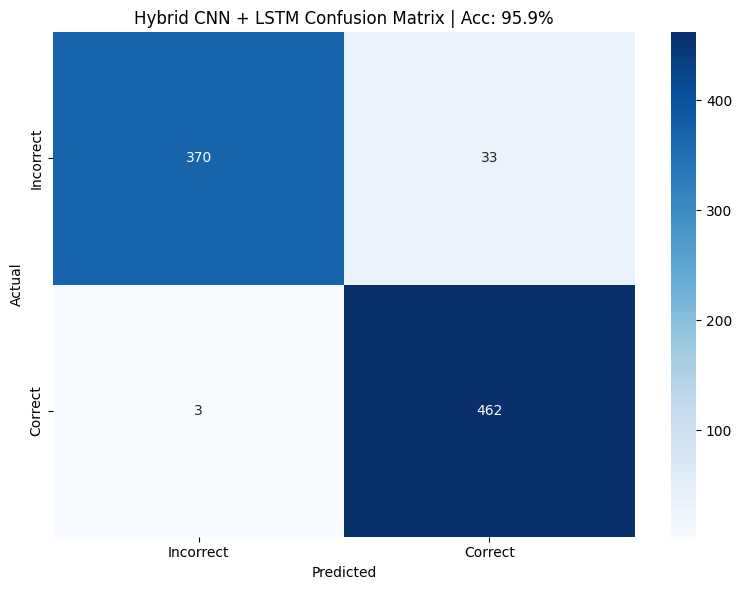

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_prob = model.predict(X_test).ravel()

print("Prediction distribution:")
print("Min:", y_pred_prob.min())
print("Max:", y_pred_prob.max())
print("Mean:", y_pred_prob.mean())

y_pred = (y_pred_prob >= best_threshold).astype(int)

print("\nUsed Threshold:", round(best_threshold, 2))
print("Predicted 0s:", (y_pred == 0).sum())
print("Predicted 1s:", (y_pred == 1).sum())

test_acc = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Incorrect", "Correct"]
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Incorrect", "Correct"],
    yticklabels=["Incorrect", "Correct"]
)

plt.title(f"Hybrid CNN + LSTM Confusion Matrix | Acc: {test_acc*100:.1f}%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
print("Actual test distribution:")
print("Incorrect:", (y_test == 0).sum())
print("Correct:", (y_test == 1).sum())

print("\nPredicted test distribution:")
print("Incorrect:", (y_pred == 0).sum())
print("Correct:", (y_pred == 1).sum())

Actual test distribution:
Incorrect: 403
Correct: 465

Predicted test distribution:
Incorrect: 373
Correct: 495


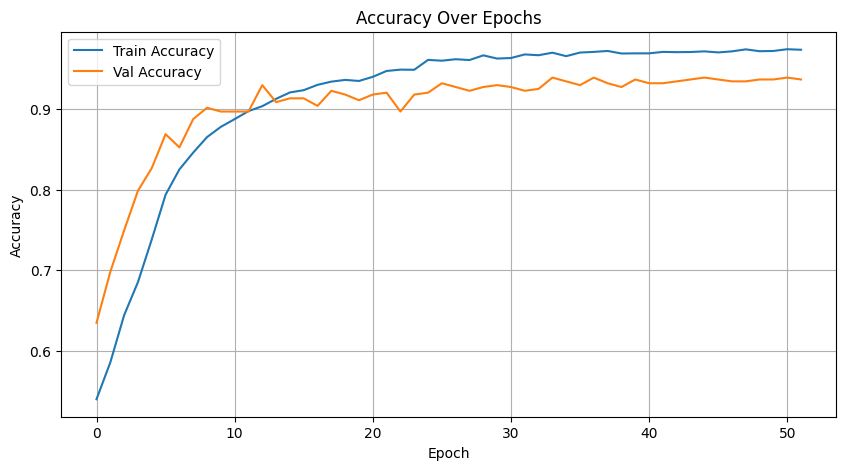

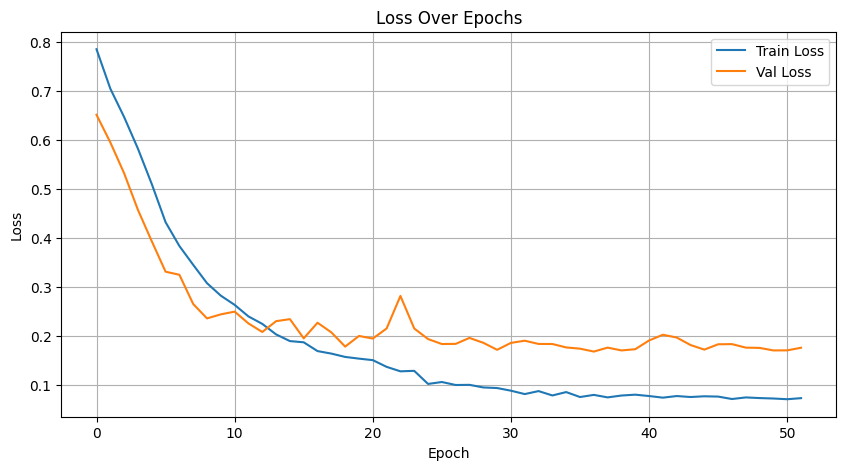

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.save(os.path.join(BASE_PATH, "final_hybrid_cnn_lstm.keras"))
model.save("final_hybrid_cnn_lstm.keras")

print("✅ Saved to Drive:")
print(os.path.join(BASE_PATH, "final_hybrid_cnn_lstm.keras"))

print("\n✅ Saved locally:")
print("final_hybrid_cnn_lstm.keras")

✅ Saved to Drive:
/content/drive/MyDrive/REHAB24-6/final_hybrid_cnn_lstm.keras

✅ Saved locally:
final_hybrid_cnn_lstm.keras


In [ ]:
from google.colab import files
import os

model.save('best_model.h5')


files.download('best_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>